# AdvViT — single-image attack test

Runs the hard-label black-box AdvViT attack (patch-wise DCT + Sign-OPT) against one image, then reports and visualizes the result.

Run this from inside `/home/siddharthsajjive/AdvViT` (Jupyter kernel using the `tea` conda env) so the relative imports (`simp`, `models.DeiT`, `models.resnet`) resolve correctly.

In [10]:
import os
import torch
from PIL import Image
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt

from simp import SimP
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

device = torch.device('cuda', 0)
print('CUDA available:', torch.cuda.is_available())
print('Device:', device)

CUDA available: True
Device: cuda:0


## 1. Choose and load a model

Uncomment exactly one `MODEL_CHOICE = ...` line below, leave the rest commented. All are already wired into the loading block underneath -- no other code changes needed to switch.

**Note on `patch_size` (used later, in the attack cell):** every model below expects 224x224 input. All of them tokenize in 16x16 patches *except* `ViT_B`, which uses 32x32 patches -- if you select `ViT_B`, also change `patch_size = 16` to `patch_size = 32` in the attack cell, or the DCT masking will misalign with the model's actual tokenization. Swin's *internal* patch size is technically 4, but the paper itself evaluates Swin with the attack's `patch_size` left at 16 (it only tunes patch size against DeiT-T), so 16 is correct for the Swin rows too, not a bug.

In [11]:
# ---- uncomment ONE of these ----
# MODEL_CHOICE = 'DeiT_T'
# MODEL_CHOICE = 'DeiT_S'
# MODEL_CHOICE = 'DeiT_B'
# MODEL_CHOICE = 'ResNet18'
# MODEL_CHOICE = 'ResNet50'
MODEL_CHOICE = 'ResNet101'
# MODEL_CHOICE = 'ResNet152'
# MODEL_CHOICE = 'VGG16'
# MODEL_CHOICE = 'Swin_T'
# MODEL_CHOICE = 'Swin_S'
# MODEL_CHOICE = 'Swin_B'
# MODEL_CHOICE = 'ViT_B'   # patch_size=32, not 16 -- see note above

if MODEL_CHOICE == 'DeiT_T':
    from models.DeiT import deit_tiny_patch16_224
    model = deit_tiny_patch16_224(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'DeiT_S':
    from models.DeiT import deit_small_patch16_224
    model = deit_small_patch16_224(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'DeiT_B':
    from models.DeiT import deit_base_patch16_224
    model = deit_base_patch16_224(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'ResNet18':
    import torchvision
    model = torchvision.models.resnet18(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'ResNet50':
    from models.resnet import ResNet50
    model = ResNet50(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'ResNet101':
    from models.resnet import ResNet101
    model = ResNet101(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'ResNet152':
    from models.resnet import ResNet152
    model = ResNet152(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'VGG16':
    import torchvision
    model = torchvision.models.vgg16(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'Swin_T':
    import timm
    model = timm.models.create_model('swin_tiny_patch4_window7_224', pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'Swin_S':
    import timm
    model = timm.models.create_model('swin_small_patch4_window7_224', pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'Swin_B':
    import timm
    model = timm.models.create_model('swin_base_patch4_window7_224', pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'ViT_B':
    import timm
    model = timm.create_model('vit_base_patch32_224.augreg_in1k', pretrained=True).to(device).eval()
else:
    raise ValueError(f'Unknown MODEL_CHOICE: {MODEL_CHOICE}')

print(f'Loaded {MODEL_CHOICE}')

Loading......
Loaded ResNet101


## 2. Load and preview the input image

`IMAGE_PATH` must be a Linux-style path (forward slashes), not a Windows one.

The image is resized to 224x224 and kept in raw `[0,1]` range — `SimP.normalize()` applies ImageNet mean/std internally, so don't normalize it yourself here.

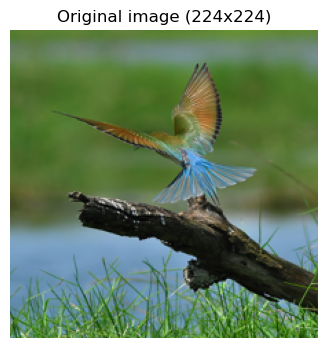

In [12]:
IMAGE_PATH = '/home/siddharthsajjive/TEA/ATTACK/ILSVRC2012_val_pairs/2b.JPEG' 
#IMAGE_PATH = '/home/siddharthsajjive/AdvViT/save/ori/ori0.jpg' # <-- change this

img = Image.open(IMAGE_PATH).convert('RGB').resize((224, 224))
x0 = T.ToTensor()(img).to(device)  # [3,224,224], range [0,1]

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title('Original image (224x224)')
plt.axis('off')
plt.show()

## 3. Get the clean prediction

This is `y0` — the label the untargeted attack will try to push the model *away* from.

In [13]:
attacker = SimP(model, 'imagenet', image_size=224)

with torch.no_grad():
    y0 = attacker.get_label(x0.unsqueeze(0))

print(f'Clean prediction (class index): {y0.item()}')

Clean prediction (class index): 92


## 8. AD vs AD+ comparison (same image, same model)

Runs plain Sign-OPT (AdvViT / "AD", `use_sign_opt_plus=False`) and the Sign-OPT+ gated version (AdvViT+ / "AD+", `use_sign_opt_plus=True`) back to back on the exact same `x0`/`y0` from cells 3-4 above, using the same `model`/`patch_num`/`QUERY_LIMIT`. Requires the `use_sign_opt_plus` parameter added to `attack_untargeted` in `simp.py` -- if you get a `TypeError: unexpected keyword argument`, your `simp.py` doesn't have that edit yet.

This runs the attack twice, so expect roughly double the wait of a single run.

In [ ]:
import time

patch_size = 16
patch_num = 224 // patch_size
QUERY_LIMIT = 4000

print('Running AD (plain Sign-OPT)...')
t0 = time.time()
adv_ad, distortion_ad, success_ad, queries_ad, prub_ad = attacker.attack_untargeted(
    x0, y0, ori_probal=None, patch_num=patch_num,
    query_limit=QUERY_LIMIT, use_sign_opt_plus=False
)
time_ad = time.time() - t0
print(f'AD finished in {time_ad:.1f}s ({time_ad/60:.2f} min)')

print('\nRunning AD+ (Sign-OPT+ gated)...')
t0 = time.time()
adv_adp, distortion_adp, success_adp, queries_adp, prub_adp = attacker.attack_untargeted(
    x0, y0, ori_probal=None, patch_num=patch_num,
    query_limit=QUERY_LIMIT, use_sign_opt_plus=True
)
time_adp = time.time() - t0
print(f'AD+ finished in {time_adp:.1f}s ({time_adp/60:.2f} min)')

print(f'\nBoth runs finished. AD+ was {time_ad/time_adp:.2f}x the speed of AD (>1 means AD+ faster).')

Running AD (plain Sign-OPT)...
Searching for the initial direction on 100 random directions: 
--------> Found l2distortion 29.1626,dctdistortion31.8763
--------> Found l2distortion 17.3489,dctdistortion18.1931
--------> Found l2distortion 16.3662,dctdistortion17.2664
--------> Found l2distortion 16.1741,dctdistortion16.9719
--------> Found l2distortion 12.0863,dctdistortion12.5849
==========> Found best distortion 12.0863using 1528 queries


/home/siddharthsajjive/AdvViT/simp.py:313: RuntimeWarning: invalid value encountered in multiply
  adv, prub= self.generate_adv(x0,patch_num,new_lbd_dct*new_theta_dct)
/home/siddharthsajjive/AdvViT/simp.py:351: RuntimeWarning: invalid value encountered in multiply
  adv, prub= self.generate_adv(x0,patch_num,new_lbd_dct*new_theta_dct)


--------> sign opt attack  4.5571
AD finished in 235.5s (3.92 min)

Running AD+ (Sign-OPT+ gated)...
Searching for the initial direction on 100 random directions: 
--------> Found l2distortion 21.7051,dctdistortion23.3634
--------> Found l2distortion 14.7892,dctdistortion15.5967
--------> Found l2distortion 13.9265,dctdistortion14.6448
==========> Found best distortion 13.9265using 1504 queries
--------> sign opt attack  4.4896
AD+ finished in 237.1s (3.95 min)

Both runs finished. AD+ was 0.99x the speed of AD (>1 means AD+ faster).


## 5. Results — attack outcome, L2 distortion, SSIM, PSNR

In [15]:
ori_np = x0.detach().cpu().permute(1, 2, 0).numpy()
adv_ad_np = adv_ad.squeeze(0).detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
adv_adp_np = adv_adp.squeeze(0).detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()

ssim_ad = ssim_fn(ori_np, adv_ad_np, channel_axis=2, data_range=1.0)
psnr_ad = psnr_fn(ori_np, adv_ad_np, data_range=1.0)
ssim_adp = ssim_fn(ori_np, adv_adp_np, channel_axis=2, data_range=1.0)
psnr_adp = psnr_fn(ori_np, adv_adp_np, data_range=1.0)

with torch.no_grad():
    pred_ad = attacker.get_label(adv_ad.to(device) if adv_ad.dim() == 4 else adv_ad.unsqueeze(0).to(device))
    pred_adp = attacker.get_label(adv_adp.to(device) if adv_adp.dim() == 4 else adv_adp.unsqueeze(0).to(device))

print(f'{"Metric":<20}{"AD":>15}{"AD+":>15}')
print('-' * 50)
print(f'{"Success":<20}{str(bool(success_ad)):>15}{str(bool(success_adp)):>15}')
print(f'{"Queries used":<20}{queries_ad:>15}{queries_adp:>15}')
print(f'{"L2 distortion":<20}{distortion_ad:>15.4f}{distortion_adp:>15.4f}')
print(f'{"SSIM":<20}{ssim_ad:>15.4f}{ssim_adp:>15.4f}')
print(f'{"PSNR (dB)":<20}{psnr_ad:>15.2f}{psnr_adp:>15.2f}')
print(f'{"Predicted class":<20}{pred_ad.item():>15}{pred_adp.item():>15}')

Metric                           AD            AD+
--------------------------------------------------
Success                        True           True
Queries used                   4106           4066
L2 distortion                4.5571         4.4896
SSIM                         0.9730         0.9744
PSNR (dB)                     38.60          38.73
Predicted class                 319            723


Image saved to AdvViT/save


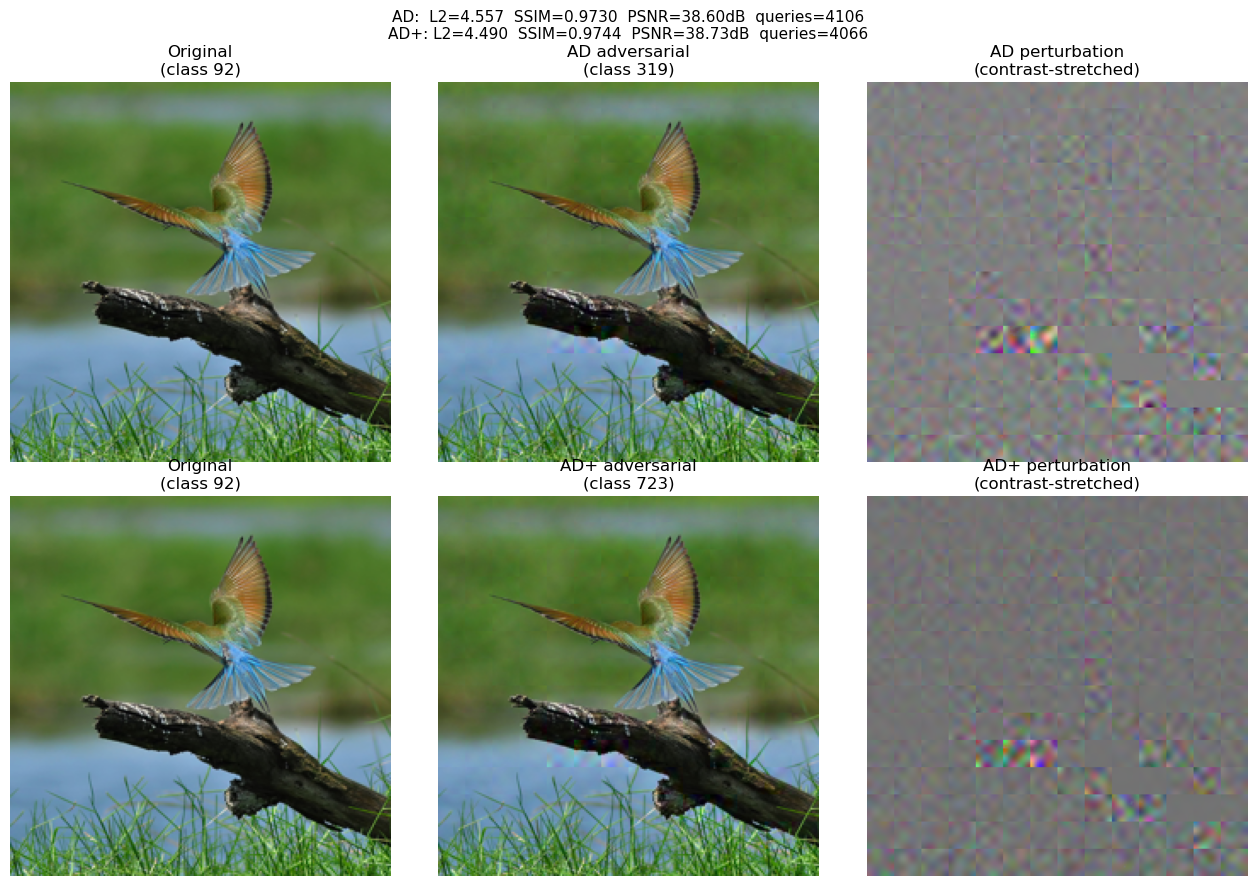

In [16]:
SAVE_NAME = f'tortoise_{MODEL_CHOICE}'
print("Image saved to AdvViT/save") 

diff_ad = adv_ad_np - ori_np
diff_ad_vis = (diff_ad - diff_ad.min()) / (diff_ad.max() - diff_ad.min() + 1e-8)
diff_adp = adv_adp_np - ori_np
diff_adp_vis = (diff_adp - diff_adp.min()) / (diff_adp.max() - diff_adp.min() + 1e-8)

fig, axes = plt.subplots(2, 3, figsize=(13, 9))

axes[0, 0].imshow(ori_np); axes[0, 0].set_title(f'Original\n(class {y0.item()})'); axes[0, 0].axis('off')
axes[0, 1].imshow(adv_ad_np); axes[0, 1].set_title(f'AD adversarial\n(class {pred_ad.item()})'); axes[0, 1].axis('off')
axes[0, 2].imshow(diff_ad_vis); axes[0, 2].set_title('AD perturbation\n(contrast-stretched)'); axes[0, 2].axis('off')

axes[1, 0].imshow(ori_np); axes[1, 0].set_title(f'Original\n(class {y0.item()})'); axes[1, 0].axis('off')
axes[1, 1].imshow(adv_adp_np); axes[1, 1].set_title(f'AD+ adversarial\n(class {pred_adp.item()})'); axes[1, 1].axis('off')
axes[1, 2].imshow(diff_adp_vis); axes[1, 2].set_title('AD+ perturbation\n(contrast-stretched)'); axes[1, 2].axis('off')

fig.suptitle(
    f'AD:  L2={distortion_ad:.3f}  SSIM={ssim_ad:.4f}  PSNR={psnr_ad:.2f}dB  queries={queries_ad}\n'
    f'AD+: L2={distortion_adp:.3f}  SSIM={ssim_adp:.4f}  PSNR={psnr_adp:.2f}dB  queries={queries_adp}',
    fontsize=11
)
plt.tight_layout()
plt.show()

save_dir = '/home/siddharthsajjive/AdvViT/save'
os.makedirs(save_dir, exist_ok=True)
fig.savefig(os.path.join(save_dir, f'output_advsad+_{SAVE_NAME}.png'), dpi=150, bbox_inches='tight')